In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

In [32]:
pd.read_json("docker_stats_log_streaming.jsonl", lines=True).head()

,timestamp_utc,container
0,2025-10-24 23:53:35.444130+00:00,"{'BlockIO': '0B / 0B', 'CPUPerc': '0.00%', 'Co..."
1,2025-10-24 23:53:35.444301+00:00,"{'BlockIO': '0B / 0B', 'CPUPerc': '0.01%', 'Co..."
2,2025-10-24 23:53:35.444366+00:00,"{'BlockIO': '98.3kB / 221kB', 'CPUPerc': '0.00..."
3,2025-10-24 23:53:35.444404+00:00,"{'BlockIO': '303kB / 0B', 'CPUPerc': '0.00%', ..."
4,2025-10-24 23:53:35.444436+00:00,"{'BlockIO': '0B / 0B', 'CPUPerc': '0.22%', 'Co..."


In [23]:
df = pd.read_json("docker_stats_log_streaming.jsonl", lines=True)

df_stats_achatados = pd.json_normalize(df['container'])
df_final = pd.concat([df['timestamp_utc'], df_stats_achatados], axis=1)
df_final['timestamp_utc'] = pd.to_datetime(df_final['timestamp_utc'])

df_final[df_final["Name"] == 'processing'][['timestamp_utc', 'CPUPerc']].sort_values(by='timestamp_utc', ascending=True)

,timestamp_utc,CPUPerc
0,2025-10-24 23:53:35.444130+00:00,0.00%
5,2025-10-24 23:53:35.444465+00:00,0.00%
10,2025-10-24 23:53:35.944038+00:00,0.00%
15,2025-10-24 23:53:35.944330+00:00,0.00%
20,2025-10-24 23:53:36.443824+00:00,0.00%
...,...,...
1425,2025-10-24 23:54:46.445273+00:00,5.33%
1430,2025-10-24 23:54:46.944280+00:00,13.46%
1435,2025-10-24 23:54:46.944630+00:00,13.46%
1440,2025-10-24 23:54:47.444403+00:00,13.46%


Carregando dados do log...
Gráfico salvo com sucesso em: consumo_cpu_e_memoria_comparativo.png


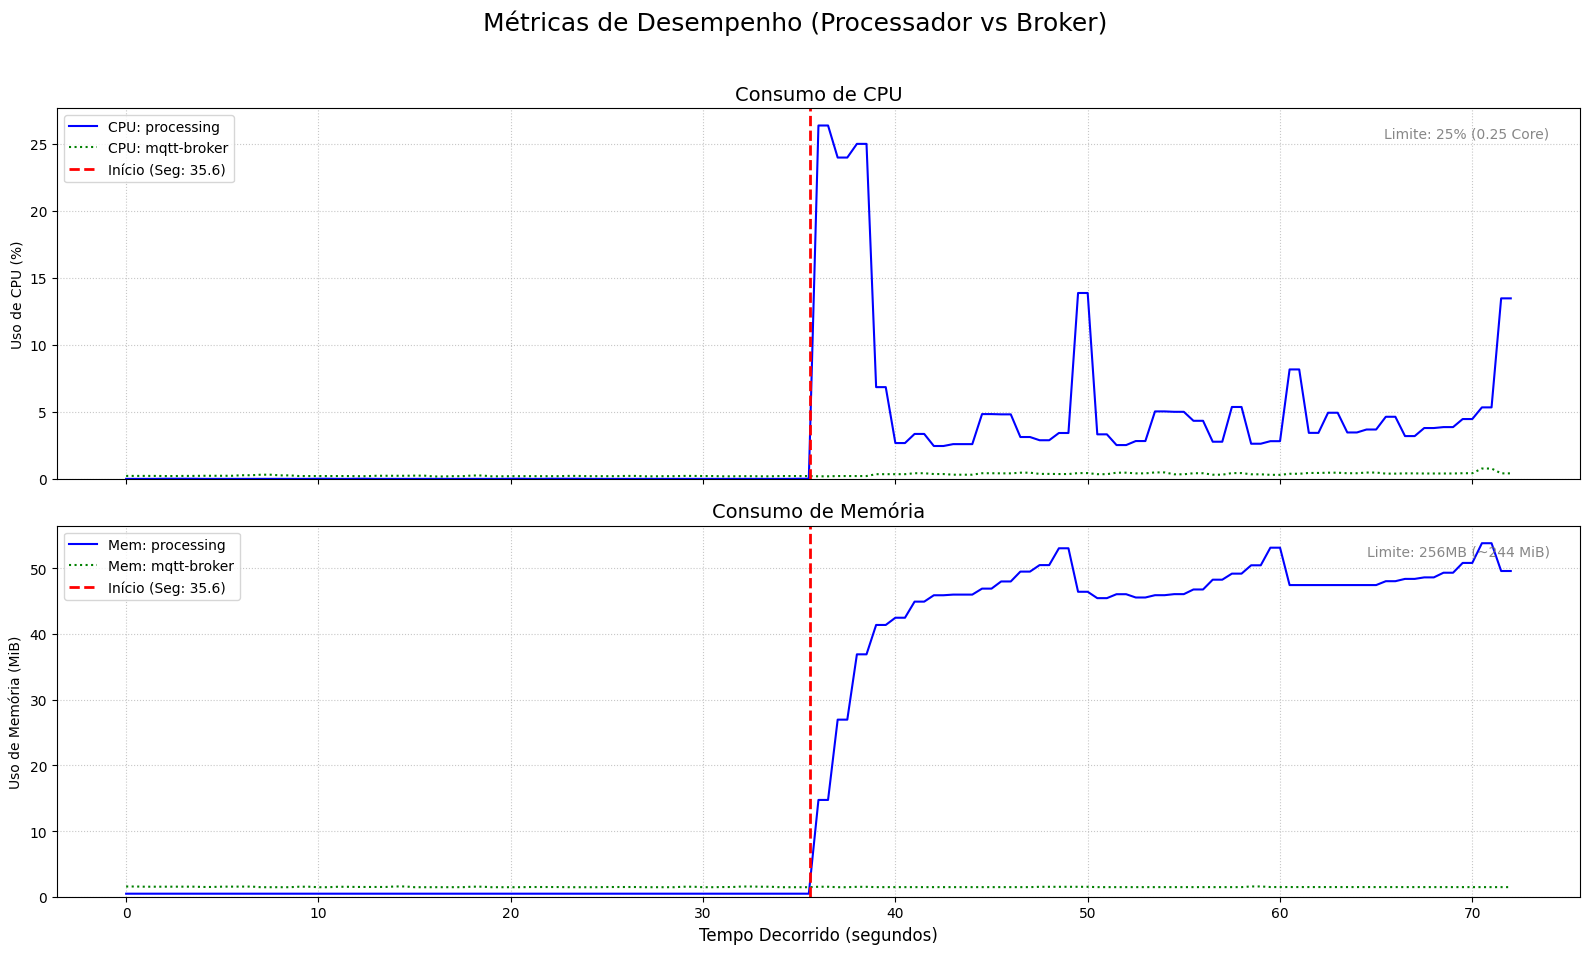

In [44]:
#!/usr/bin/env python3

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import sys
import re

def carregar_stats_para_dataframe(filepath="docker_stats_log_streaming.jsonl"):
    """
    Carrega o arquivo .jsonl de logs do Docker Stats para um DataFrame Pandas.
    """
    try:
        df_bruto = pd.read_json(filepath, lines=True)
        if df_bruto.empty:
            print(f"Aviso: O arquivo '{filepath}' está vazio.", file=sys.stderr)
            return None
        df_stats_achatados = pd.json_normalize(df_bruto['container'])
        df_final = pd.concat([df_bruto['timestamp_utc'], df_stats_achatados], axis=1)
        df_final['timestamp_utc'] = pd.to_datetime(df_final['timestamp_utc'])
        return df_final
    except FileNotFoundError:
        print(f"Erro: Arquivo não encontrado em '{filepath}'", file=sys.stderr)
        return None
    except ValueError as e:
        print(f"Erro ao processar o arquivo JSON: {e}", file=sys.stderr)
        return None
    except Exception as e:
        print(f"Um erro inesperado ocorreu: {e}", file=sys.stderr)
        return None

def parse_mem_usage_to_mib(mem_string):
    """
    Converte a string de 'MemUsage' (ex: "19.57MiB / 15.35GiB")
    para um valor float em MebiBytes (MiB).
    """
    try:
        # Pega a primeira parte (o uso): "19.57MiB"
        usage_part = mem_string.split(' / ')[0].strip()

        # Encontra o número e a unidade
        match = re.match(r"([\d\.]+)([a-zA-Z]+)", usage_part)
        if not match:
            return None

        value = float(match.group(1))
        unit = match.group(2).lower()

        # Converte tudo para MiB
        if unit == 'gib':
            return value * 1024
        elif unit == 'mib':
            return value
        elif unit == 'kib':
            return value / 1024
        elif unit == 'b':
            return value / (1024 * 1024)
        else:
            return value # Assume MiB se desconhecido

    except Exception:
        return None # Retorna None se a string for mal formatada

def plotar_metricas(df, container_proc, container_broker, start_time_str, output_filename):
    """
    Plota o uso de CPU e Memória para dois containers em subplots separados,
    com um marcador de início de processamento e linhas de limite.
    O eixo X mostra o tempo decorrido em segundos, começando em 0.
    """
    if df is None or df.empty:
        print("DataFrame está vazio. Não é possível plotar.", file=sys.stderr)
        return

    # --- 1. Preparar Dados ---

    # --- NOVO: Calcular tempo decorrido ---
    # Pega o primeiro timestamp de toda a coleta
    t_start = df['timestamp_utc'].min()
    # Cria uma nova coluna 'elapsed_seconds' com o tempo em segundos
    # desde o início da coleta.
    df['elapsed_seconds'] = (df['timestamp_utc'] - t_start).dt.total_seconds()
    # --- FIM DA MUDANÇA ---

    # Converte a data de início para datetime
    try:
        start_time_dt = pd.to_datetime(start_time_str)
        start_time_dt = start_time_dt.tz_localize(df['timestamp_utc'].dt.tz)

        # --- NOVO: Converter o marcador para segundos decorridos ---
        # Calcula em que segundo (relativo a t_start) o processamento começou
        start_time_elapsed_seconds = (start_time_dt - t_start).total_seconds()
        # --- FIM DA MUDANÇA ---

    except Exception as e:
        print(f"Erro ao converter a data/hora de início '{start_time_str}': {e}", file=sys.stderr)
        return

    # Filtrar e preparar dados dos containers
    containers = {
        container_proc: df[df['Name'] == container_proc].copy(),
        container_broker: df[df['Name'] == container_broker].copy()
    }

    if containers[container_proc].empty:
        print(f"Erro: Nenhum dado para o container de processamento '{container_proc}'", file=sys.stderr)
        return
    if containers[container_broker].empty:
        print(f"Erro: Nenhum dado para o container broker '{container_broker}'", file=sys.stderr)
        return

    # Limpar dados de CPU e Memória (sem alteração aqui)
    for name, df_c in containers.items():
        df_c['cpu_perc_num'] = df_c['CPUPerc'].str.replace('%', '').astype(float)
        df_c['mem_mib_num'] = df_c['MemUsage'].apply(parse_mem_usage_to_mib)

    # --- 2. Criar a Figura e os Subplots ---

    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    fig.suptitle(f'Métricas de Desempenho (Processador vs Broker)', fontsize=18)

    # --- 3. Subplot Superior: CPU (axes[0]) ---
    ax_cpu = axes[0]

    # --- MUDANÇA: Usar 'elapsed_seconds' no eixo X ---
    ax_cpu.plot(
        containers[container_proc]['elapsed_seconds'],
        containers[container_proc]['cpu_perc_num'],
        label=f'CPU: {container_proc}',
        linewidth=1.5,
        color='blue'
    )
    ax_cpu.plot(
        containers[container_broker]['elapsed_seconds'],
        containers[container_broker]['cpu_perc_num'],
        label=f'CPU: {container_broker}',
        linewidth=1.5,
        color='green',
        linestyle=':'
    )

    # --- MUDANÇA: Usar 'start_time_elapsed_seconds' para o marcador ---
    ax_cpu.axvline(x=start_time_elapsed_seconds, color='red', linestyle='--', linewidth=2, label=f'Início (Seg: {start_time_elapsed_seconds:.1f})')

    # Anotação de limite de CPU (sem alteração, usa transAxes)
    ax_cpu.text(
        0.98, 0.95, "Limite: 25% (0.25 Core)",
        transform=ax_cpu.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        color='dimgray', alpha=0.8
    )

    ax_cpu.set_title('Consumo de CPU', fontsize=14)
    ax_cpu.set_ylabel('Uso de CPU (%)')
    ax_cpu.legend(loc='upper left')
    ax_cpu.grid(True, linestyle=':', alpha=0.7)
    ax_cpu.set_ylim(bottom=0)

    # --- 4. Subplot Inferior: Memória (axes[1]) ---
    ax_mem = axes[1]

    # --- MUDANÇA: Usar 'elapsed_seconds' no eixo X ---
    ax_mem.plot(
        containers[container_proc]['elapsed_seconds'],
        containers[container_proc]['mem_mib_num'],
        label=f'Mem: {container_proc}',
        linewidth=1.5,
        color='blue'
    )
    ax_mem.plot(
        containers[container_broker]['elapsed_seconds'],
        containers[container_broker]['mem_mib_num'],
        label=f'Mem: {container_broker}',
        linewidth=1.5,
        color='green',
        linestyle=':'
    )

    # --- MUDANÇA: Usar 'start_time_elapsed_seconds' para o marcador ---
    ax_mem.axvline(x=start_time_elapsed_seconds, color='red', linestyle='--', linewidth=2, label=f'Início (Seg: {start_time_elapsed_seconds:.1f})')

    # Anotação de limite de Memória (sem alteração, usa transAxes)
    mem_limit_mib = (256 * 10**6) / (2**20) # ~244.14 MiB
    ax_mem.text(
        0.98, 0.95, f"Limite: 256MB (~{mem_limit_mib:.0f} MiB)",
        transform=ax_mem.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        color='dimgray', alpha=0.8
    )

    ax_mem.set_title('Consumo de Memória', fontsize=14)
    ax_mem.set_ylabel('Uso de Memória (MiB)')

    # --- MUDANÇA: Atualizar o label do eixo X ---
    ax_mem.set_xlabel('Tempo Decorrido (segundos)', fontsize=12)
    # --- FIM DA MUDANÇA ---

    ax_mem.legend(loc='upper left')
    ax_mem.grid(True, linestyle=':', alpha=0.7)
    ax_mem.set_ylim(bottom=0)

    # --- 5. Finalizar e Salvar ---

    # --- MUDANÇA: Remover formatadores de data ---
    # Não precisamos mais formatar o eixo X como Data/Hora
    # ax_mem.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S')) # REMOVIDO
    # fig.autofmt_xdate() # REMOVIDO
    # --- FIM DA MUDANÇA ---

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])

    try:
        plt.savefig(output_filename, dpi=150)
        print(f"Gráfico salvo com sucesso em: {output_filename}")
    except Exception as e:
        print(f"Erro ao salvar o gráfico: {e}", file=sys.stderr)

# --- PONTO DE ENTRADA DO SCRIPT ---
if __name__ == "__main__":

    # --- CONFIGURE AQUI ---
    # 1. Nome do container de processamento principal
    NOME_PROCESSADOR = "processing"

    # 2. Nome do container do broker
    NOME_BROKER = "mqtt-broker"

    # 3. Timestamp UTC de quando o processamento REAL começou
    INICIO_PROCESSAMENTO_UTC = "2025-10-24 23:54:11"

    # 4. Nome do arquivo de log
    ARQUIVO_LOG = "docker_stats_log_streaming.jsonl"

    # 5. Nome do arquivo de imagem que será gerado
    ARQUIVO_GRAFICO = "consumo_cpu_e_memoria_comparativo.png"
    # ----------------------

    print("Carregando dados do log...")
    df_completo = carregar_stats_para_dataframe(ARQUIVO_LOG)

    if df_completo is not None:
        plotar_metricas(
            df_completo,
            NOME_PROCESSADOR,
            NOME_BROKER,
            INICIO_PROCESSAMENTO_UTC,
            ARQUIVO_GRAFICO
        )
    else:
        print("Não foi possível carregar os dados. Saindo.", file=sys.stderr)
        sys.exit(1)

Plotando dados para o container 'processing'...
Gráfico salvo com sucesso em: plot.png


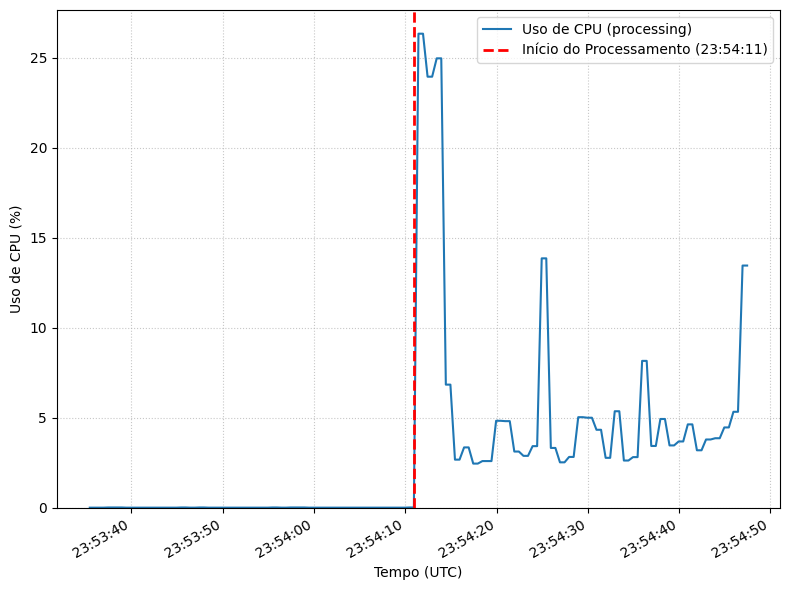

In [30]:
# 1. Filtrar pelo container desejado
# Usamos .copy() para evitar o 'SettingWithCopyWarning' do Pandas
container_name = "processing"
start_time_str =

# 2. Limpar a coluna 'CPUPerc'
# Converte a string "10.50%" para o número float 10.50
df['cpu_perc_num'] = df['CPUPerc'].str.replace('%', '').astype(float)

# 3. Converter a string de tempo de início para um objeto datetime
# O Pandas é ótimo para "adivinhar" o formato da string.
start_time_dt = pd.to_datetime(start_time_str)

# --- 4. Plotagem com Matplotlib ---

print(f"Plotando dados para o container '{container_name}'...")

# Define o tamanho da figura (largura, altura) em polegadas
plt.figure(figsize=(8, 6))
ax = plt.gca() # Pega o eixo atual

# Plotar a série temporal de CPU
ax.plot(
    df['timestamp_utc'],
    df['cpu_perc_num'],
    label=f'Uso de CPU ({container_name})',
    linewidth=1.5
)

# Plotar a linha vertical (marcador)
ax.axvline(
    x=start_time_dt,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Início do Processamento ({start_time_dt.strftime("%H:%M:%S")})'
)

# --- 5. Melhorias e Labels ---

# Título e labels dos eixos
#ax.set_title(f'Consumo de CPU do Container: {container_name}', fontsize=16)
ax.set_xlabel('Tempo (UTC)', fontsize=10)
ax.set_ylabel('Uso de CPU (%)', fontsize=10)

# Adicionar legenda
ax.legend(fontsize=10)

# Adicionar grid
ax.grid(True, linestyle=':', alpha=0.7)

# Definir o limite inferior do eixo Y para 0
ax.set_ylim(bottom=0)

# Formatar o eixo X para mostrar datas/horas de forma legível
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.gcf().autofmt_xdate() # Rotaciona as datas para não sobrepor

# Ajusta o layout para evitar corte de labels
plt.tight_layout()

# Salvar a imagem
output_filename = "plot.png"
plt.savefig(output_filename, dpi=150) # dpi=150 para boa resolução
print(f"Gráfico salvo com sucesso em: {output_filename}")